# Bayes Distance Clustering

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyLasaDataset as lasa
from scipy.interpolate import make_splrep
from tqdm.auto import tqdm

Using LASA DataSet from /home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/pyLasaDataset/resources/LASAHandwritingDataset/DataSet


In [2]:
import torch
from torch.nn.functional import softplus
from torch.autograd import grad
from torch.autograd.functional import hessian
import hamiltorch
from sklearn import cluster, datasets, mixture
from scipy.spatial import distance
from statsmodels.tsa.stattools import acf
import pymc as pm3
import arviz
# %matplotlib inline

/home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
# select device: change to 'cpu' if there's no GPU device
device = "cpu"

dtype = "double"

if device == "gpu":
    torch.cuda.set_device(0)

    if dtype == "float":
        torch.set_default_tensor_type(torch.cuda.FloatTensor)
        dtype_ = torch.float32
    else:
        torch.set_default_tensor_type(torch.cuda.DoubleTensor)
        dtype_ = torch.double


if device == "cpu":
    # torch.set_default_tensor_type(torch.DoubleTensor)
    torch.set_default_dtype(torch.float64)
    dtype_ = torch.double

In [4]:
hamiltorch.set_random_seed(123)

In [5]:
# N,P = int(200),5
torch.manual_seed(123)

## Lasa

In [6]:
# DataSet object has all the LASA handwriting data files
# as attributes, eg:
angle_data = lasa.DataSet.Angle
sine_data = lasa.DataSet.Sine


# Each Data object has attributes dt and demos (For documentation,
# refer original dataset repo:
# https://bitbucket.org/khansari/lasahandwritingdataset/src/master/Readme.txt)
dt = angle_data.dt
demos = angle_data.demos  # list of 7 Demo objects, each corresponding to a
# repetition of the pattern


# Each Demo object in demos list will have attributes pos, t, vel, acc
# corresponding to the original .mat format described in
# https://bitbucket.org/khansari/lasahandwritingdataset/src/master/Readme.txt
demo_0 = demos[0]
pos = demo_0.pos  # np.ndarray, shape: (2,2000)
vel = demo_0.vel  # np.ndarray, shape: (2,2000)
acc = demo_0.acc  # np.ndarray, shape: (2,2000)
t = demo_0.t  # np.ndarray, shape: (1,2000)


# # To visualise the data (2D position and velocity) use the plot_model utility
# lasa.utilities.plot_model(lasa.DataSet.BendedLine) # give any of the available
#                                                    # pattern data as argument

In [7]:
!ls /home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/pyLasaDataset/resources/LASAHandwritingDataset/DataSet

Angle.mat	      Khamesh.mat	  Multi_Models_4.mat  Spoon.mat
BendedLine.mat	      Leaf_1.mat	  NShape.mat	      Sshape.mat
CShape.mat	      Leaf_2.mat	  PShape.mat	      Trapezoid.mat
DoubleBendedLine.mat  Line.mat		  RShape.mat	      Worm.mat
GShape.mat	      LShape.mat	  Saeghe.mat	      WShape.mat
heee.mat	      Multi_Models_1.mat  Sharpc.mat	      Zshape.mat
JShape_2.mat	      Multi_Models_2.mat  Sine.mat
JShape.mat	      Multi_Models_3.mat  Snake.mat


In [8]:
def plot_model(data):
    pos_data = [d.pos for d in data.demos]
    speed_data = [np.sqrt(np.sum(d.vel**2, 0)) for d in data.demos]

    with plt.style.context("ggplot"):
        fig = plt.figure()

        fig.suptitle(data.name, fontsize=16)

        f1_ax1 = plt.subplot(2, 1, 1)
        f1_ax1.set_title("Position Trajectory")

        f1_ax2 = plt.subplot(2, 1, 2)
        f1_ax2.set_title("Speed Profile")

        for i, vals in enumerate(pos_data):
            lines = f1_ax1.plot(vals[0, :], vals[1, :], "k", alpha=0.7)
            start = f1_ax1.scatter(vals[0, 0], vals[1, 0], c="k", marker="x")
            target = f1_ax1.scatter(vals[0, -1], vals[1, -1], c="k", marker="*")
            f1_ax2.plot(speed_data[i], "k", alpha=0.7)

        start.set_label("Starting Points")
        target.set_label("Target")

        f1_ax1.set_xlabel("x (mm)")
        f1_ax1.set_ylabel("y (mm)")

        f1_ax2.set_xlabel("time (s)")
        f1_ax2.set_ylabel("speed (mm/s)")
        f1_ax1.legend()
        # plt.axis('tight')
        fig.tight_layout()
        plt.show()

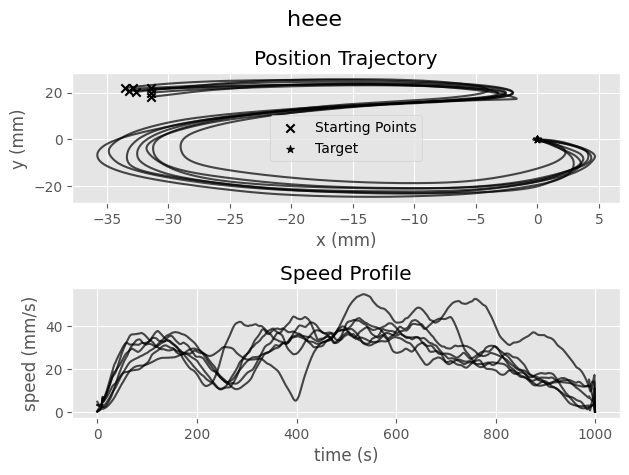

In [9]:
plot_model(lasa.DataSet.heee)

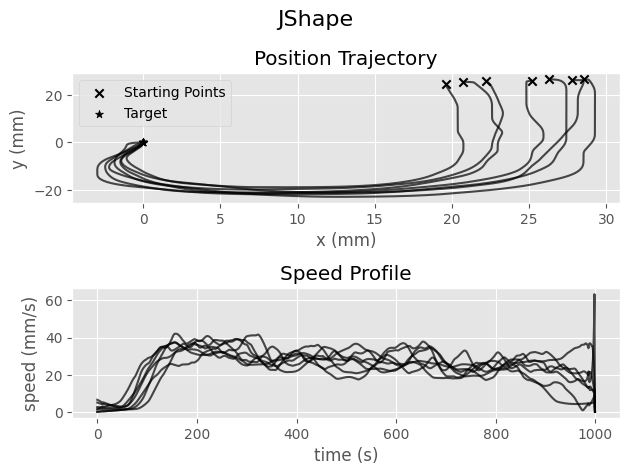

In [10]:
plot_model(lasa.DataSet.JShape)

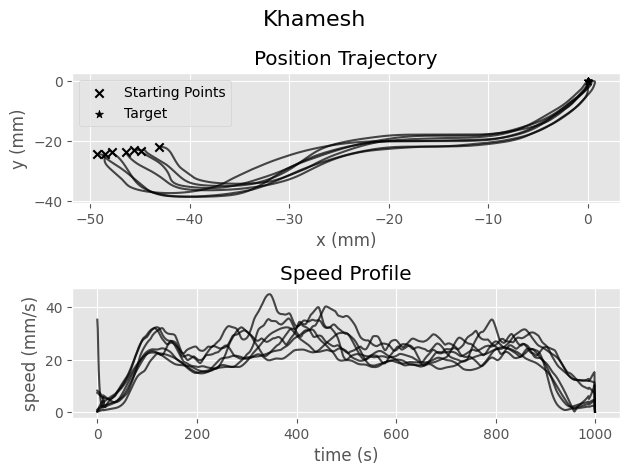

In [11]:
plot_model(lasa.DataSet.Khamesh)

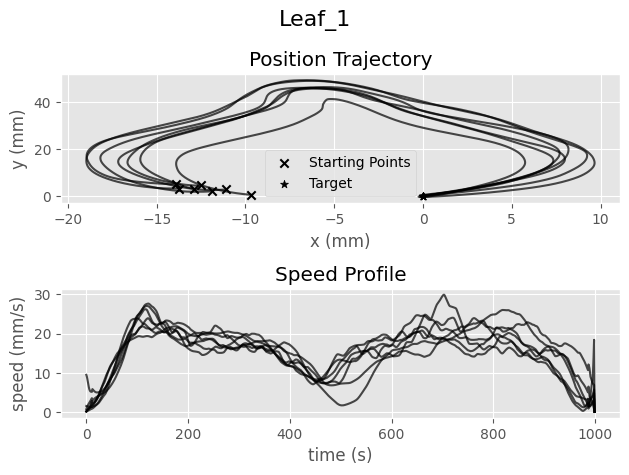

In [12]:
plot_model(lasa.DataSet.Leaf_1)

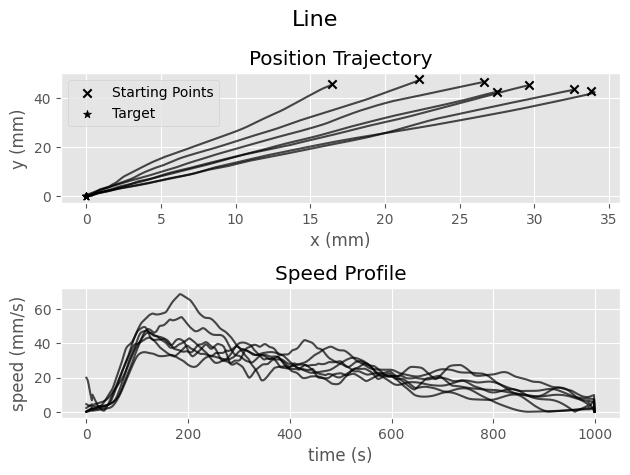

In [13]:
plot_model(lasa.DataSet.Line)

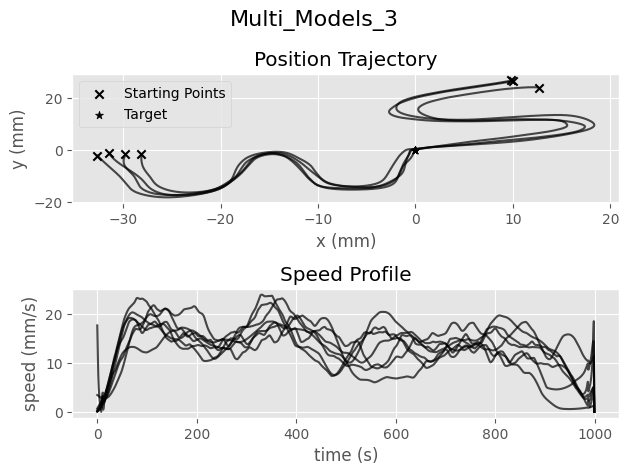

In [14]:
plot_model(lasa.DataSet.Multi_Models_3)

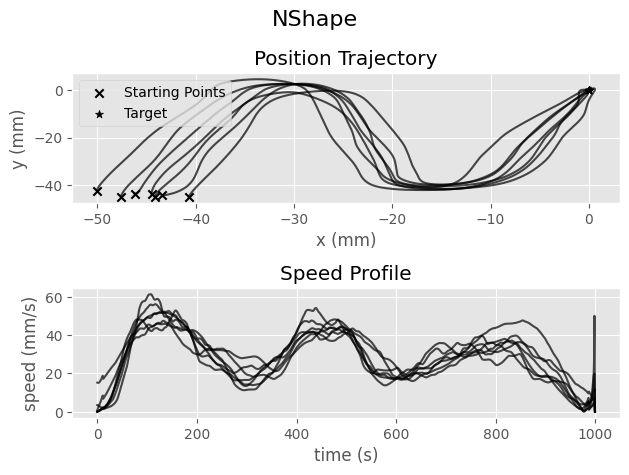

In [15]:
plot_model(lasa.DataSet.NShape)

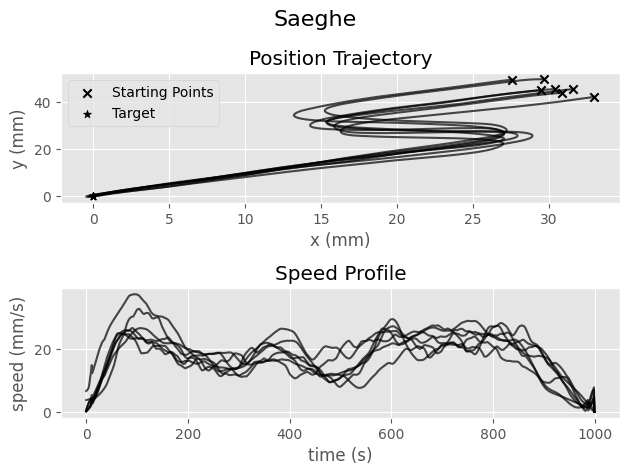

In [16]:
plot_model(lasa.DataSet.Saeghe)

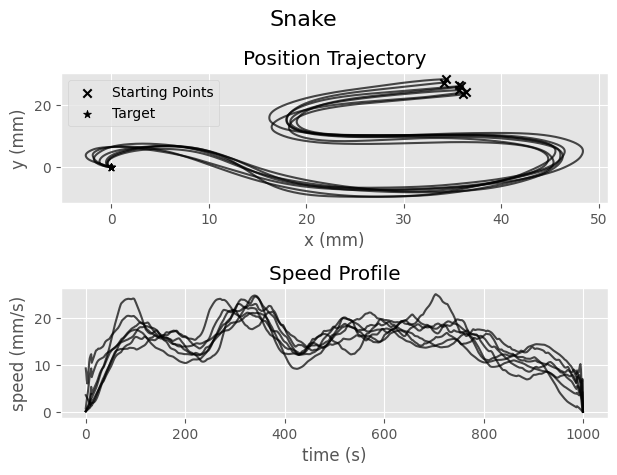

In [17]:
plot_model(lasa.DataSet.Snake)

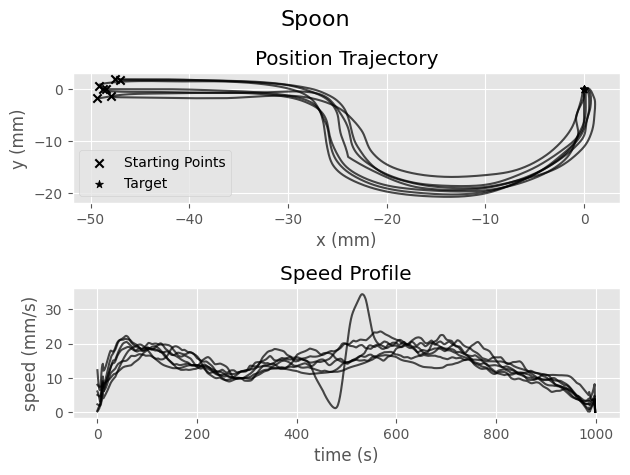

In [18]:
plot_model(lasa.DataSet.Spoon)

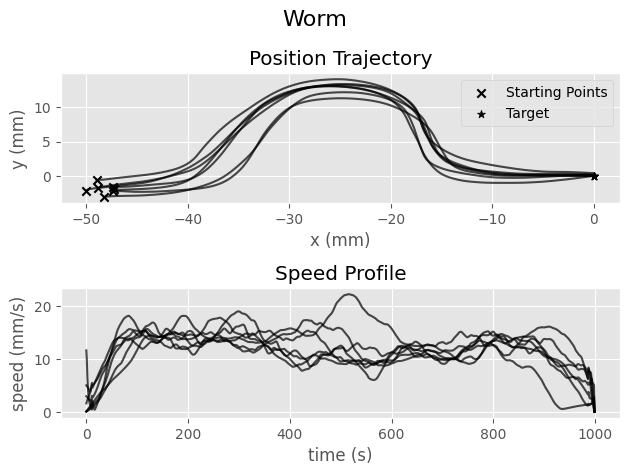

In [19]:
plot_model(lasa.DataSet.Worm)

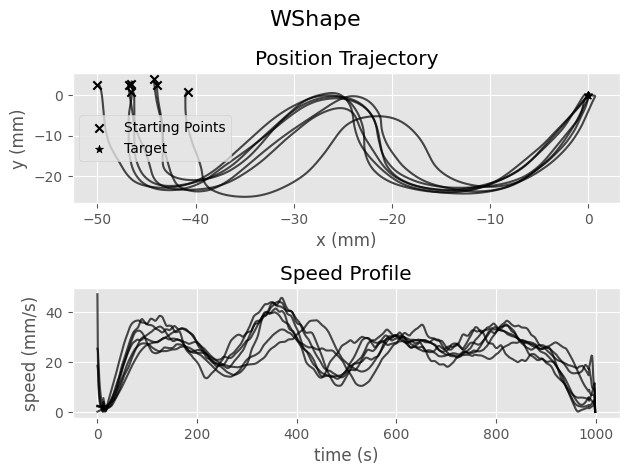

In [20]:
plot_model(lasa.DataSet.WShape)

## Data

In [21]:
# n_samples = 10

# blobs = datasets.make_blobs(n_samples=n_samples, random_state=0, shuffle=False)
# blobs

In [22]:
resample_num = 2**7
# resample_num = 10
print(f"Resampling to {resample_num} data points")
smoothing_factor = 0

Resampling to 128 data points


In [23]:
def smooth_arr(arr, nb_points=256, smoothing_factor=0):
    index_ori = np.arange(start=0, stop=arr.shape[0])
    new_index = np.linspace(start=0, stop=arr.shape[0], num=nb_points)
    arr_smooth = make_splrep(x=index_ori, y=arr, s=smoothing_factor)(new_index)
    return arr_smooth

In [24]:
datasets = [lasa.DataSet.heee, lasa.DataSet.Line, lasa.DataSet.Saeghe]
X = None
classes = None
for idx, data in enumerate(datasets):
    # dt = data.dt
    demos = data.demos
    demo_id = 0
    demo = demos[demo_id]
    pos = demo.pos.T
    pos_resampled = smooth_arr(
        arr=pos, nb_points=resample_num, smoothing_factor=smoothing_factor
    )
    if X is None:
        X = np.hstack((np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled))
        classes = np.ones((pos_resampled.shape[0],)) * idx
    else:
        # dist_from_last_point = np.abs(X[-1, :] - pos_resampled[0, :])
        pos_with_time = np.hstack(
            (np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled)
        )
        # X = np.vstack((X, pos_resampled - dist_from_last_point))
        X = np.vstack((X, pos_with_time))
        classes = np.hstack((classes, np.ones(pos_resampled.shape[0]) * idx))
# X = np.hstack((np.arange(X.shape[0])[:, np.newaxis], X))
print(X.shape)
print(classes.shape)
blobs = [X, classes]

(384, 3)
(384,)


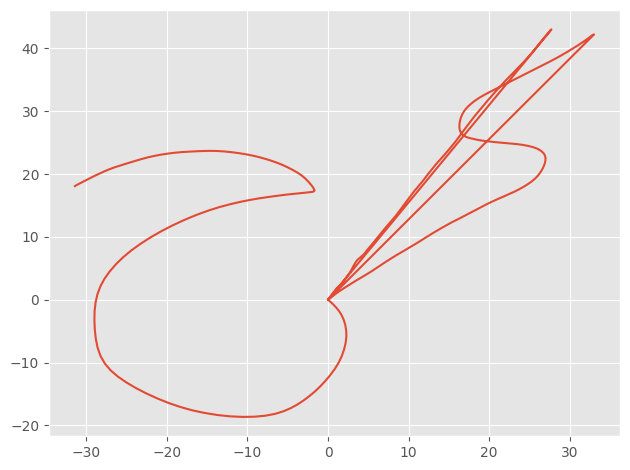

In [25]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(blobs[0][:, 1], blobs[0][:, 2])  # , c=blobs[1], alpha=0.5, s=20)
    fig.tight_layout()
    plt.show()

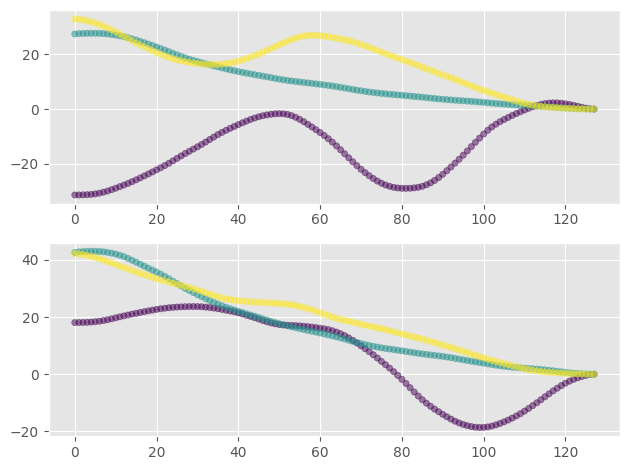

In [26]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(2, 1)
    # ax.plot(blobs[0][:, 0], blobs[0][:, 1])#, pos_resampled[1])
    ax[0].scatter(blobs[0][:, 0], blobs[0][:, 1], c=blobs[1], alpha=0.5, s=20)
    ax[1].scatter(blobs[0][:, 0], blobs[0][:, 2], c=blobs[1], alpha=0.5, s=20)
    fig.tight_layout()
    plt.show()

## Clustering

In [27]:
y = blobs[0]

In [28]:
D = distance.squareform(distance.pdist(y))
D

array([[  0.        ,   1.00016771,   2.00110474, ..., 130.15253089,
        131.11044746, 132.07083454],
       [  1.00016771,   0.        ,   1.00116049, ..., 129.19150682,
        130.1488186 , 131.10862427],
       [  2.00110474,   1.00116049,   0.        , ..., 128.22883499,
        129.18555413, 130.14478482],
       ...,
       [130.15253089, 129.19150682, 128.22883499, ...,   0.        ,
          1.00074744,   2.00066564],
       [131.11044746, 130.1488186 , 129.18555413, ...,   1.00074744,
          0.        ,   1.00008363],
       [132.07083454, 131.10862427, 130.14478482, ...,   2.00066564,
          1.00008363,   0.        ]], shape=(384, 384))

In [29]:
eps = np.finfo(float).eps

In [30]:
logD = np.log(D + eps)
print(logD)
# np.fill_diagonal(logD, 0)

[[-3.60436534e+01  1.67700258e-04  6.93699401e-01 ...  4.86870708e+00
   4.87604008e+00  4.88333840e+00]
 [ 1.67700258e-04 -3.60436534e+01  1.15981353e-03 ...  4.86129585e+00
   4.86867855e+00  4.87602617e+00]
 [ 6.93699401e-01  1.15981353e-03 -3.60436534e+01 ...  4.85381644e+00
   4.86124977e+00  4.86864756e+00]
 ...
 [ 4.86870708e+00  4.86129585e+00  4.85381644e+00 ... -3.60436534e+01
   7.47164385e-04  6.93479944e-01]
 [ 4.87604008e+00  4.86867855e+00  4.86124977e+00 ...  7.47164385e-04
  -3.60436534e+01  8.36272657e-05]
 [ 4.88333840e+00  4.87602617e+00  4.86864756e+00 ...  6.93479944e-01
   8.36272657e-05 -3.60436534e+01]]


In [31]:
D_tc = torch.tensor(D)
logD_tc = torch.tensor(logD)

In [32]:
svdD = np.linalg.svd(D)

In [33]:
p = 2

In [34]:
trunc = p + 2

In [35]:
n = y.shape[0]

In [36]:
K = 3

In [37]:
P = n * (K - 1) + K + K

In [38]:
def log_prob(theta, t=1e-1):

    idx = 0
    idx1 = n * (K - 1)

    W0 = theta[idx:idx1].reshape([n, (K - 1)])
    W1 = torch.hstack([W0, torch.zeros(n, 1)])
    W = torch.softmax((W1) / t, 1)

    prior_W0 = -1 / 9.0 / 2.0 * (W0**2).sum()

    idx = idx1
    idx1 += K
    sigma = softplus(theta[idx:idx1])

    idx = idx1
    idx1 += K
    alpha = softplus(theta[idx:idx1])

    prior_alpha = (-alpha).sum()

    n_h = torch.diag(W.T @ W)

    prior_sigma = -1000 * (sigma**2).sum()

    loglik = (
        torch.trace(W.T @ logD_tc @ W * (alpha - 1) / (n_h))
        - torch.trace(W.T @ D_tc @ W / (n_h * sigma))
        + (-n_h * (alpha * torch.log(sigma) + torch.lgamma(alpha))).sum()
        + prior_sigma
        + prior_W0
        + prior_alpha
    )

    return loglik

In [39]:
# initialization using spectral clustering
scFit = cluster.spectral_clustering(logD - D + 1e6, n_clusters=K)  # , verbose=True)

In [40]:
def one_hot(a, num_classes):
    return np.squeeze(np.eye(num_classes)[a.reshape(-1)])

In [41]:
W_init = torch.tensor(one_hot(scFit, 3))

In [42]:
W_init = torch.log(W_init + 0.1)

In [43]:
W_init -= torch.reshape(W_init[:, K - 1], [n, 1])

In [44]:
theta = torch.randn(P)

theta[: (n * (K - 1))] = (W_init[:, : (K - 1)]).flatten()

theta = theta.requires_grad_()


optimizer = torch.optim.LBFGS([theta], lr=1e-3)


def closure():
    optimizer.zero_grad()
    loss = -log_prob(theta)
    loss.backward()
    return loss


loss = []
for t in tqdm(range(100)):
    res = optimizer.step(closure)
    loss.append(res.item())
loss = np.array(loss)
print(loss)

  0%|          | 0/100 [00:00<?, ?it/s]

[37888.22074726 37343.17745049 36784.5955653  36224.8600777
 35660.37191667 35086.44050142 34496.72067736 33878.19853764
 33196.42465338 32364.06701521 31233.95538105 29923.99267219
 28798.76156508 27876.58793813 27077.76149159 26355.30978753
 25689.64110872 25079.81322824 24526.40723514 24022.15888654
 23556.74396769 23120.91541184 22707.68871648 22312.21738715
 21931.30264196 21562.85522817 21205.48534505 20858.2358085
 20520.41888983 20191.51851142 19871.13136666 19558.93070313
 19254.64326175 18958.03402325 18668.89578052 18387.04183638
 18112.30080855 17844.51289425 17583.52716188 17329.19957258
 17081.39152463 16839.96877531 16604.80063721 16375.75937608
 16152.7197577  15935.55870593 15724.15504488 15518.38930484
 15318.14357744 15123.30140906 14933.74772402 14749.36877144
 14570.05209065 14395.68649148 14226.16204624 14061.37009083
 13901.2032332  13745.55536713 13594.32169028 13447.39872507
 13304.68434157 13166.07778154 13031.47968292 12900.7921042
 12773.91854821 12650.76398

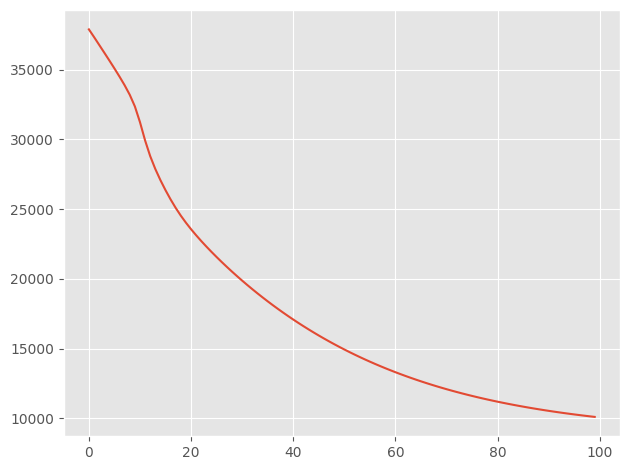

In [45]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(loss)
    fig.tight_layout()
    plt.show()

In [46]:
idx = 0
idx1 = n * (K - 1)

t = 1e-1

W0 = theta[idx:idx1].reshape([n, (K - 1)])
W1 = torch.hstack([W0, torch.zeros(n, 1)])
W = torch.softmax((W1) / t, 1)

idx = idx1
idx1 += K
sigma = softplus(theta[idx:idx1])


idx = idx1
idx1 += K
alpha = softplus(theta[idx:idx1])


n_h = torch.diag(W.T @ W)

In [47]:
W_np = W.detach().cpu().numpy()
W_np

array([[7.07764047e-11, 7.07763938e-11, 1.00000000e+00],
       [7.07764047e-11, 7.07763939e-11, 1.00000000e+00],
       [7.07764047e-11, 7.07763941e-11, 1.00000000e+00],
       ...,
       [7.07763881e-11, 1.00000000e+00, 7.07763947e-11],
       [7.07763880e-11, 1.00000000e+00, 7.07763946e-11],
       [7.07763883e-11, 1.00000000e+00, 7.07763948e-11]], shape=(384, 3))

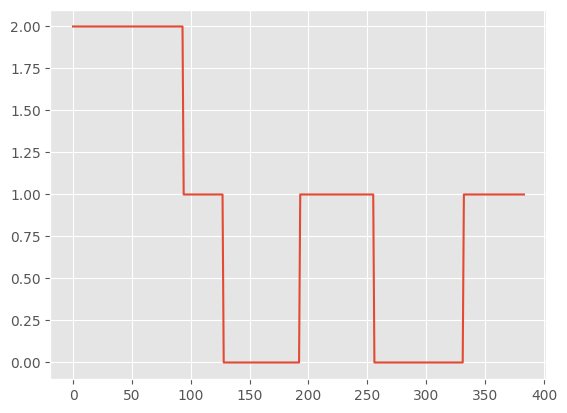

In [48]:
with plt.style.context("ggplot"):
    plt.plot((W_np @ np.diag(np.arange(3))).sum(1))
    plt.show()

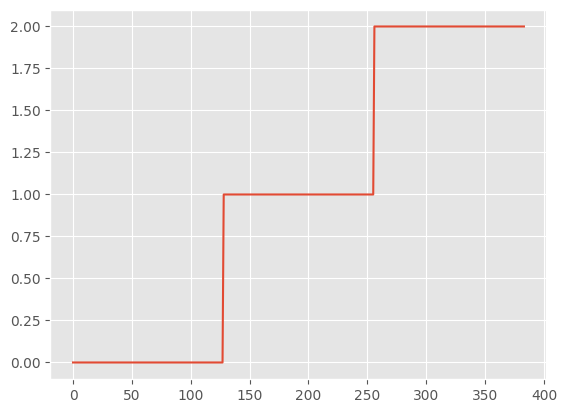

In [49]:
with plt.style.context("ggplot"):
    plt.plot(blobs[1])
    plt.show()

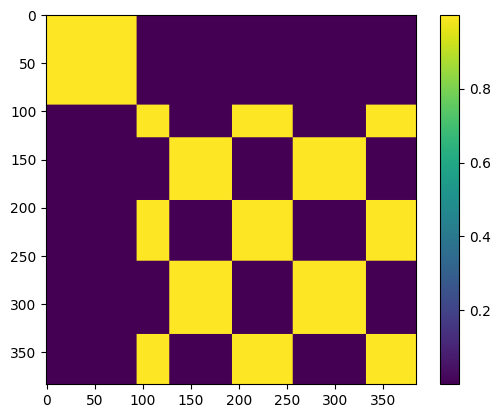

In [50]:
plt.imshow((W @ W.T).detach().numpy())
plt.colorbar()
plt.show()

In [51]:
H = hessian(log_prob, theta).diagonal()

In [52]:
inv_mass = 1.0 / H.abs()

In [53]:
# HMC NUTS

step_size = 5e-2
hamiltorch.set_random_seed(123)
params_init = theta

num_samples = 3000  # For results in plot num_samples = 12000
L = 100
burn = 1000  # For results in plot burn = 2000

params_hmc_nuts = hamiltorch.sample(
    log_prob_func=log_prob,
    params_init=params_init,
    num_samples=num_samples,
    step_size=step_size,
    num_steps_per_sample=L,
    desired_accept_rate=0.6,
    sampler=hamiltorch.Sampler.HMC_NUTS,
    burn=burn,
    inv_mass=inv_mass,
)

Sampling (Sampler.HMC; Integrator.IMPLICIT)
Time spent  | Time remain.| Progress             | Samples   | Samples/sec


/home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/hamiltorch/samplers.py:626: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(-h_new + h_old)


Final Adapted Step Size:  0.0006922593456692994- |  999/3000 | 7.32        
0d:00:06:55 | 0d:00:00:00 | #################### | 3000/3000 | 7.23       
Acceptance Rate 0.60


In [54]:
def extractW2(i):
    idx = 0
    idx1 = n * (K - 1)

    t = 1e-1

    W0 = theta[idx:idx1].reshape([n, (K - 1)])
    W1 = torch.hstack([W0, torch.zeros(n, 1)])
    W = torch.softmax((W1) / t, 1)
    return W @ W.T

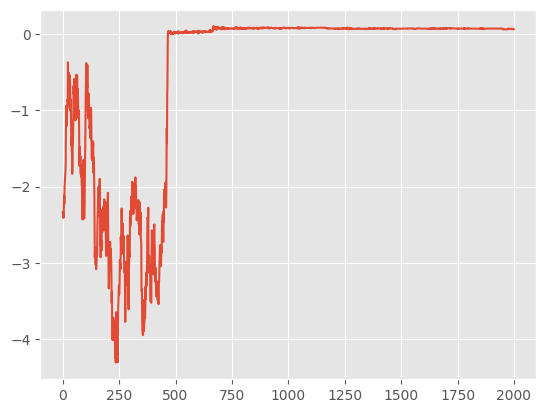

In [55]:
param_trace = torch.vstack(params_hmc_nuts)

trace_np = param_trace.detach().cpu().numpy()

with plt.style.context("ggplot"):
    plt.plot(trace_np[:, 1] * 1)
    # plt.scatter(trace_np[:,0],trace_np[:,1])
    plt.show()

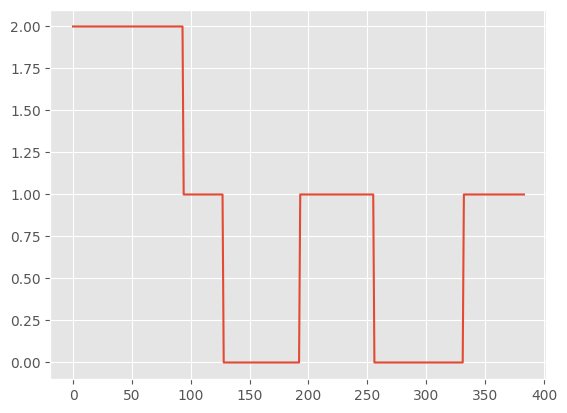

In [56]:
theta = param_trace[1,]

idx = 0
idx1 = n * (K - 1)

t = 1e-1

W0 = theta[idx:idx1].reshape([n, (K - 1)])
W1 = torch.hstack([W0, torch.zeros(n, 1)])
W = torch.softmax((W1) / t, 1)

W_np = W.detach().numpy()

with plt.style.context("ggplot"):
    plt.plot((W_np @ np.diag(np.arange(3))).sum(1))
    plt.show()

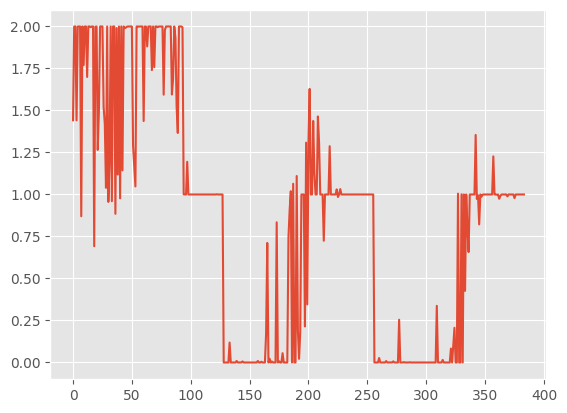

In [57]:
theta = param_trace[99,]

idx = 0
idx1 = n * (K - 1)

t = 1e-1

W0 = theta[idx:idx1].reshape([n, (K - 1)])
W1 = torch.hstack([W0, torch.zeros(n, 1)])
W = torch.softmax((W1) / t, 1)

W_np = W.detach().numpy()

with plt.style.context("ggplot"):
    plt.plot((W_np @ np.diag(np.arange(3))).sum(1))
    plt.show()

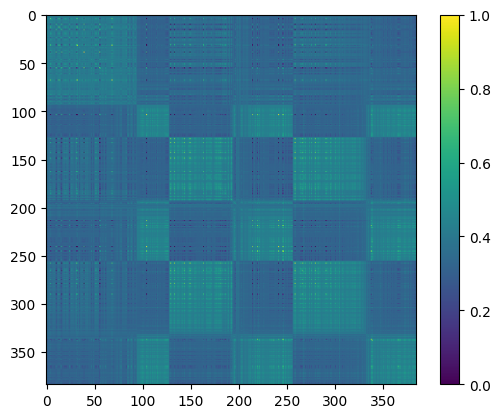

In [58]:
param_trace = torch.vstack(params_hmc_nuts)

trace_np = param_trace.detach().cpu().numpy()

# plt.plot(trace_np[:,1])

# plt.plot(trace_np[:,3])


def extractW2(i):
    theta = param_trace[i,]
    idx = 0
    idx1 = n * (K - 1)

    t = 1e-1

    W0 = theta[idx:idx1].reshape([n, (K - 1)])
    W1 = torch.hstack([W0, torch.zeros(n, 1)])
    W = torch.softmax((W1) / t, 1)
    return W @ W.T


W2 = torch.zeros([n, n])

for i in range(param_trace.shape[0]):
    W2 += extractW2(i)

W2_var = W2 / param_trace.shape[0]

plt.imshow(W2_var.detach().numpy(), vmin=0, vmax=1)
plt.colorbar()
plt.show()

In [59]:
# plt.plot(param_trace[:,4])

In [60]:
def extractC(i):
    theta = param_trace[i,]
    idx = 0
    idx1 = n * (K - 1)

    t = 1e-1

    W0 = theta[idx:idx1].reshape([n, (K - 1)])
    W1 = torch.hstack([W0, torch.zeros(n, 1)])
    C = torch.softmax((W1) / t, 1) @ np.arange(K)
    return C

In [61]:
C_trace = torch.stack([extractC(i) for i in range(2000)]).round()

/tmp/ipykernel_783720/3444894772.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C = torch.softmax((W1) / t, 1) @ np.arange(K)


In [62]:
# from pylab import rcParams

# rcParams['figure.figsize'] = 5, 4
# rcParams['figure.dpi'] = 300

In [63]:
C_trace.shape

torch.Size([2000, 384])

In [64]:
acf_mat = np.vstack([acf(param_trace[:, i], fft=False, nlags=40) for i in range(300)])

acf_mat[np.isnan(acf_mat)] = 0

acf_mat[:, 0] = 1

In [65]:
P

774

In [66]:
ess = np.stack([arviz.ess(param_trace[:, i].numpy()) for i in range(P)])

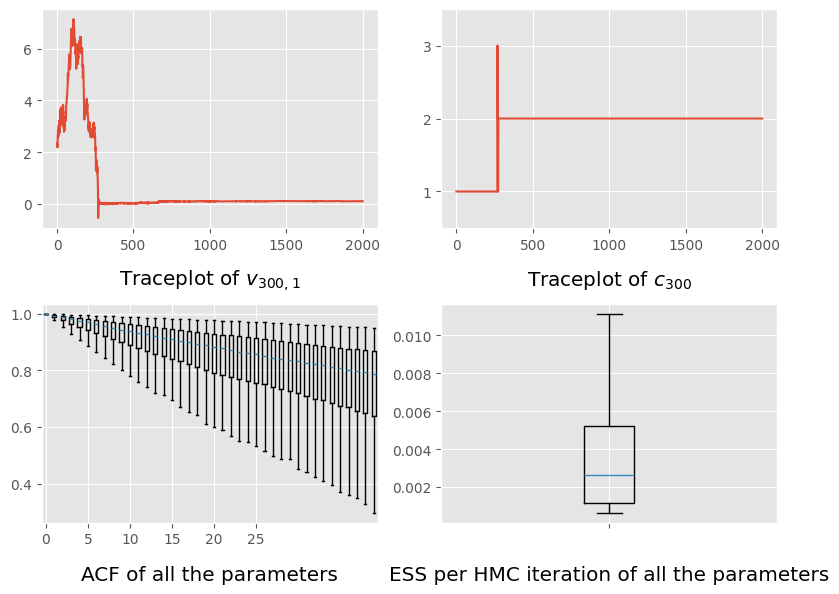

In [67]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(2, 2, gridspec_kw={"width_ratios": [1, 1]})
    fig.set_size_inches([8, 6])

    ax[0, 0].plot(param_trace[:, (299) * (K - 1)])
    ax[0, 0].set_title("Traceplot of $v_{300,1}$", y=-0.3)
    ax[0, 1].plot(np.arange(2000), C_trace[:, 299] + 1)
    ax[0, 1].set_title("Traceplot of $c_{300}$", y=-0.3)
    ax[0, 1].set_ylim([0.5, 3.5])
    ax[0, 1].set_yticks([1, 2, 3])

    ax[1, 0].boxplot(
        acf_mat[:, :40],
        showfliers=False,
    )
    ax[1, 0].set_xticks(np.arange(6) * 5 + 1)
    ax[1, 0].set_xticklabels(np.arange(6) * 5)
    ax[1, 0].set_title("ACF of all the parameters", y=-0.3)

    ax[1, 1].boxplot(
        ess / 2000,
        showfliers=False,
    )
    ax[1, 1].set_xticks([1])
    ax[1, 1].set_xticklabels([""])
    ax[1, 1].set_title("ESS per HMC iteration of all the parameters", y=-0.3)
    fig.tight_layout(pad=1)
    # fig.savefig("benchmark_hmc.png")
    plt.show()

In [68]:
idx = 0
idx1 = n * (K - 1)


W0 = theta[idx:idx1].reshape([n, (K - 1)])
W1 = torch.hstack([W0, torch.zeros(n, 1)])
W = torch.softmax((W1) / t, 1)

prior_W0 = -1 / 9.0 / 2.0 * (W0**2).sum()


idx = idx1
idx1 += K
sigma = softplus(theta[idx:idx1])


idx = idx1
idx1 += K
alpha = softplus(theta[idx:idx1])

prior_alpha = (-alpha).sum()


n_h = torch.diag(W.T @ W)

In [69]:
mapC = C_trace.mode(0)[0]

In [70]:
uncertainty = ((C_trace == mapC) * 1.0).mean(0)

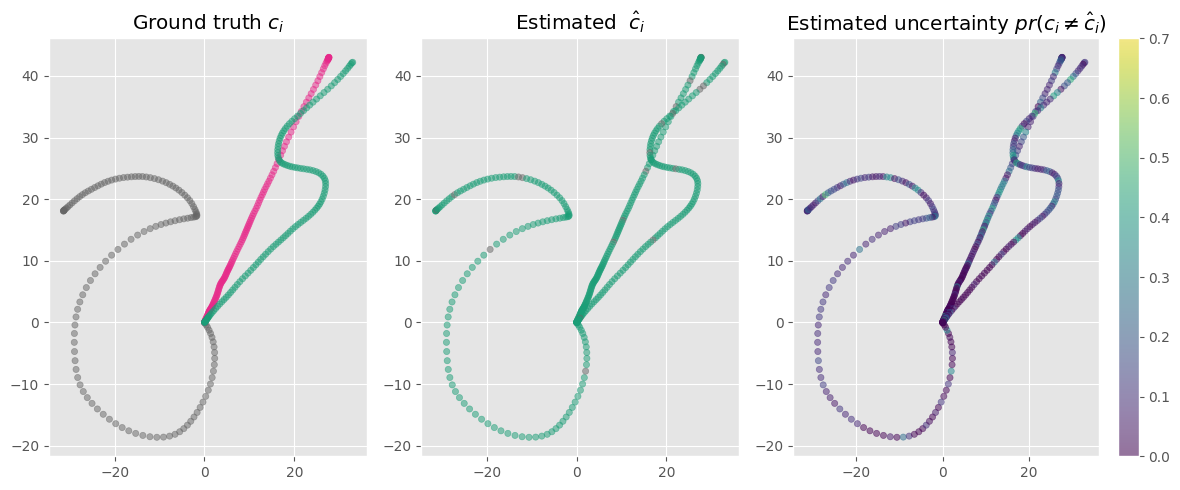

In [71]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(1, 3, gridspec_kw={"width_ratios": [1, 1, 1.2]})
    fig.set_size_inches([12, 5])

    ax[0].scatter(
        blobs[0][:, 1], blobs[0][:, 2], c=blobs[1], alpha=0.5, s=20, cmap="Dark2_r"
    )
    ax[0].set_title(r"Ground truth $c_i$")  # , y=-0.4)

    ax[1].scatter(
        blobs[0][:, 1], blobs[0][:, 2], c=mapC.numpy(), alpha=0.5, s=20, cmap="Dark2_r"
    )
    ax[1].set_title(r"Estimated  $\hat c_i$")  # , y=-0.4)

    im1 = ax[2].scatter(
        blobs[0][:, 1],
        blobs[0][:, 2],
        c=1 - uncertainty,
        alpha=0.5,
        s=20,
        # cmap="jet",
        vmin=0,
        vmax=0.7,
    )
    fig.colorbar(im1, ax=ax[2])
    ax[2].set_title(r"Estimated uncertainty $pr(c_i \neq \hat c_i)$")  # , y=-0.4)

    fig.tight_layout()  # pad=1.5)
    fig.savefig("benchmark_hmc_plot.png")
    plt.show()